# Entregable 3: Benchmark

Para un proyecto de ML hacen falta:
- Datos
- Objetivo que se debe lograr

In [34]:
import pandas as pd
import numpy as np
from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error
import seaborn as sns

In [4]:
data_path = r"C:\Users\jonmi\Documents\Nuclio\M4\4_Recursos  Aprendizaje Supervisado Time Series (1)-20260324\data\ts_kaggle_train.csv"

In [5]:
df = pd.read_csv(data_path, index_col = 0)

In [8]:
df

,date,unique_id,city_id,shop_id,item_category_id,item_id,monthly_average_price,monthly_sales
0,2013-01-31,12_11365,16,12,9,11365,1511.512626,30.0
1,2013-01-31,12_11369,16,12,9,11369,572.715278,30.0
2,2013-01-31,12_11370,16,12,9,11370,699.776786,30.0
3,2013-01-31,12_11373,16,12,9,11373,548.900000,6.0
4,2013-01-31,12_12231,16,12,49,12231,350.000000,3.0
...,...,...,...,...,...,...,...,...
14479,2015-10-31,7_5822,21,7,35,5822,NaN,NaN
14480,2015-10-31,7_6185,21,7,30,6185,NaN,NaN
14481,2015-10-31,7_6497,21,7,28,6497,NaN,NaN
14482,2015-10-31,7_7856,21,7,28,7856,NaN,NaN


In [9]:
df["unique_id"].nunique()

426

In [ ]:
#Data from Jan2013 to Sep2015 --> goal is to predict oct2015
sorted(df["date"].unique())[-2:]

['2015-09-30', '2015-10-31']

df de ts multivariante: diferentes tiendas e items, predicción de ventas mensuales con precio medio mensual

In [ ]:
df.head() 

,date,unique_id,city_id,shop_id,item_category_id,item_id,monthly_average_price,monthly_sales
0,2013-01-31,12_11365,16,12,9,11365,1511.512626,30.0
1,2013-01-31,12_11369,16,12,9,11369,572.715278,30.0
2,2013-01-31,12_11370,16,12,9,11370,699.776786,30.0
3,2013-01-31,12_11373,16,12,9,11373,548.900000,6.0
4,2013-01-31,12_12231,16,12,49,12231,350.000000,3.0


In [16]:
df.tail() #No hay datos de octubre 2015, que es lo que queremos predecir

,date,unique_id,city_id,shop_id,item_category_id,item_id,monthly_average_price,monthly_sales
14479,2015-10-31,7_5822,21,7,35,5822,NaN,NaN
14480,2015-10-31,7_6185,21,7,30,6185,NaN,NaN
14481,2015-10-31,7_6497,21,7,28,6497,NaN,NaN
14482,2015-10-31,7_7856,21,7,28,7856,NaN,NaN
14483,2015-10-31,7_7893,21,7,6,7893,NaN,NaN


## Primer EDA:

1. Preprocessing: Imputaciones y limpieza
2. Feature Engineering --> favorecer análisis si tengo pocas variables
3. train-test-split
4. Modelo
5. Predict

In [18]:
df.describe() #nos centramos en las variables numéricas, sin los ids

,city_id,shop_id,item_category_id,item_id,monthly_average_price,monthly_sales
count,14484.000000,14484.000000,14484.000000,14484.000000,13262.000000,13756.000000
mean,10.833333,31.967136,39.356808,8626.431925,916.089314,7.337889
std,6.227364,15.236351,20.439654,5905.273346,820.945949,7.915032
min,0.000000,3.000000,2.000000,32.000000,4.928571,0.000000
25%,7.000000,22.000000,30.000000,4248.000000,299.000000,2.000000
50%,7.000000,31.000000,35.000000,6457.000000,649.000000,5.000000
75%,16.000000,44.000000,55.000000,12551.000000,1149.000000,9.000000
max,23.000000,59.000000,83.000000,22088.000000,9305.121212,30.000000


<Axes: xlabel='monthly_sales'>

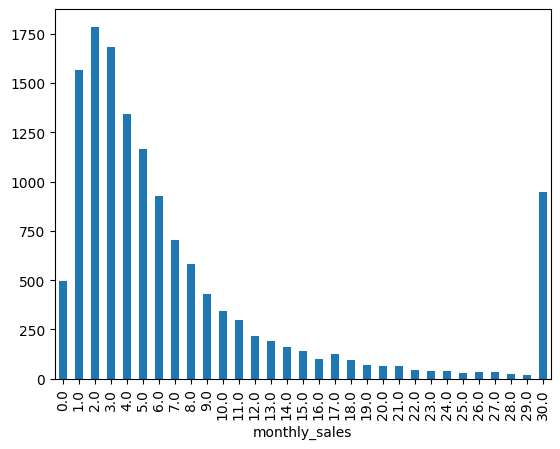

In [ ]:
#Las ventas se han limitado a 30 unidades, para prevenir que métricas como el RMSE se vean muy afectadas por outliers. 
#Sin embargo, esto hace que el número de ventas mensuales sea un dato discreto, con un número limitado de valores posibles.
df["monthly_sales"].value_counts().sort_index().plot(kind="bar")

In [ ]:
#Comparación de métricas para dos predicciones hipotéticas
y_true = [8,7,15,10,45]
y_pred1 = [7,8,12,8,40]
y_pred2 = [8,7,15,10,35]
print("RMSE pred1:", root_mean_squared_error(y_true, y_pred1))
print("MAE pred1:", mean_absolute_error(y_true, y_pred1))
print("RMSE pred2:", root_mean_squared_error(y_true, y_pred2))
print("MAE pred2:", mean_absolute_error(y_true, y_pred2))

RMSE pred1: 2.8284271247461903
MAE pred1: 2.4
RMSE pred2: 4.47213595499958
MAE pred2: 2.0


In [22]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 14484 entries, 0 to 14483
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   14484 non-null  object 
 1   unique_id              14484 non-null  object 
 2   city_id                14484 non-null  int64  
 3   shop_id                14484 non-null  int64  
 4   item_category_id       14484 non-null  int64  
 5   item_id                14484 non-null  int64  
 6   monthly_average_price  13262 non-null  float64
 7   monthly_sales          13756 non-null  float64
dtypes: float64(2), int64(4), object(2)
memory usage: 1018.4+ KB


In [23]:
df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d")

In [ ]:
df.head()                                                                                                                                                    

,date,unique_id,city_id,shop_id,item_category_id,item_id,monthly_average_price,monthly_sales
0,2013-01-31,12_11365,16,12,9,11365,1511.512626,30.0
1,2013-01-31,12_11369,16,12,9,11369,572.715278,30.0
2,2013-01-31,12_11370,16,12,9,11370,699.776786,30.0
3,2013-01-31,12_11373,16,12,9,11373,548.900000,6.0
4,2013-01-31,12_12231,16,12,49,12231,350.000000,3.0


### 1.1. Comprobar que la ts es completa, que no falte ningún mes

In [27]:
assert_message = "Tus TS no son completas. Revisa el dataset"
assert df["unique_id"].nunique() * df["date"].nunique() == df.shape[0], assert_message #426 * 34, nos debe dar las filas del dataset: 14484

Si la ts no está completa:
- En ventas: dependiendo del contexto, lo más seguro es asimilar que no hubo ventas. Se crea el registro y las ventas se dejan en 0.
- Se pueden compiar los datos del año anterior y reemplazarlos de forma artificial pero con cierta lógica.
- Interpolación

<Axes: xlabel='unique_id', ylabel='date'>

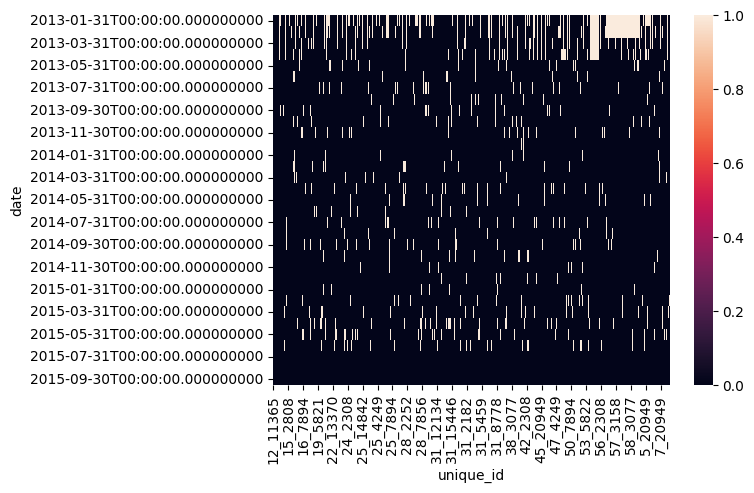

In [35]:
# chaining
pt = (
    df
    .pivot_table(
        index="date",
        columns="unique_id",
        values="monthly_sales"
    )
    .replace({0:np.nan})
    .isnull()
)

sns.heatmap(pt, cbar=True)

In [ ]:
# En este caso, se rellenan los valores faltantes con 0, dado que en time series no se deben eliminar filas
df["monthly_sales"] = df["monthly_sales"].fillna(0)

### 1.2. Imputación de monthly_av_price

In [109]:
ts = df[df["unique_id"]=="31_4249"][["date", "monthly_average_price"]].set_index("date")

In [114]:
ts["mean"] = ts["monthly_average_price"].fillna(ts["monthly_average_price"].mean())
ts["interpolation"] = ts["monthly_average_price"].interpolate()
ts["front"] = ts["monthly_average_price"].ffill()
ts["back"] = ts["monthly_average_price"].bfill()
ts["front_back"] = ts["monthly_average_price"].bfill().ffill()

Cuidado con los valores de octubre y cómo se hace el bfill y ffill --> se debe hacer a través de groupby

In [115]:
ts

,monthly_average_price,mean,interpolation,front,back,front_back
date,,,,,,
2013-01-31,1899.000000,1899.000000,1899.000000,1899.000000,1899.000000,1899.000000
2013-02-28,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
2013-03-31,1013.416000,1013.416000,1013.416000,1013.416000,1013.416000,1013.416000
2013-04-30,1598.900000,1598.900000,1598.900000,1598.900000,1598.900000,1598.900000
2013-05-31,1598.937500,1598.937500,1598.937500,1598.937500,1598.937500,1598.937500
2013-06-30,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
2013-07-31,1399.000000,1399.000000,1399.000000,1399.000000,1399.000000,1399.000000
2013-08-31,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
2013-09-30,1199.000000,1199.000000,1199.000000,1199.000000,1199.000000,1199.000000


In [116]:
df.groupby(["unique_id"])["monthly_sales"].sum()

unique_id
12_11365    674.0
12_11369    947.0
12_11370    986.0
12_11373    862.0
12_12231     78.0
            ...  
7_5822      274.0
7_6185      100.0
7_6497      156.0
7_7856      161.0
7_7893      121.0
Name: monthly_sales, Length: 426, dtype: float64

### 1.2.1. Transform
Devuelve misma cantidad de filas que el df, no agrupa por categorías
Cuidado con rellenar datos del mes de Octubre, deberían estar vacíos o sin alterar

In [118]:
df["monthly_average_price_bf"] = df.groupby(["unique_id"])["monthly_average_price"].transform(
    lambda series: series.bfill().ffill()
)

# Entregable

### El mes con el mayor número de ventas ha sido (todos los artículos): dic2014 con 4874


In [ ]:
df_month_sum = (
    df
    .groupby("date")["monthly_sales"]
    .sum()
    .rename("total_sales")
    .to_frame()
    #.describe()
    #.plot(subplots=True, figsize=(12,8))
)

In [ ]:
df_month_sum[df_month_sum["total_sales"] == max(df_month_sum["total_sales"])]

,total_sales
date,
2014-12-31,4874.0


### Id de ciudad con más ventas: 7 con 41360 ventas

In [53]:
df_city_sum = (
    df
    .groupby("city_id")["monthly_sales"]
    .sum()
    .rename("total_sales_city")
    .to_frame()
    #.describe()
    #.plot(subplots=True, figsize=(12,8))
)

In [55]:
df_city_sum[df_city_sum["total_sales_city"] == max(df_city_sum["total_sales_city"])]

,total_sales_city
city_id,
7,41360.0


### El id de la categoría con los mayores ingresos en el mes de Septiembre-2015 es: 35 con 825643.73 €

In [64]:
df["income"] = df["monthly_sales"] * df["monthly_average_price"]

In [70]:
df_item_category_id_sum = (
    df
    [df["date"] == "2015-09-30"]
    .groupby("item_category_id")["income"]
    .sum().round(2)
    .rename("total_income_category")
    .to_frame()
    #.describe()
    #.plot(subplots=True, figsize=(12,8))
)

In [71]:
df_item_category_id_sum

,total_income_category
item_category_id,
2,47150.00
6,228514.08
9,94139.65
19,23176.50
21,3994.50
22,6495.00
23,65890.58
28,74185.02
30,90001.88


In [97]:
df_item_category_id_sum[df_item_category_id_sum["total_income_category"] == max(df_item_category_id_sum["total_income_category"])]

,total_income_category
item_category_id,
35,825643.73


### El id de la categoría que tiene mayor número de item_id diferentes es: 40 con 24 item_id diferentes

In [98]:
df_item_per_category_nunique = (
    df
    .groupby("item_category_id")["item_id"]
    .nunique()
    .rename("total_items_per_category")
    .to_frame()
    #.describe()
    #.plot(subplots=True, figsize=(12,8))
)

In [99]:
df_item_per_category_nunique

,total_items_per_category
item_category_id,
2,1
6,3
9,4
19,3
21,1
22,1
23,5
28,2
30,12


In [100]:
df_item_per_category_nunique[df_item_per_category_nunique["total_items_per_category"] == max(df_item_per_category_nunique["total_items_per_category"])]

,total_items_per_category
item_category_id,
40,24


In [101]:
#Verificación
df[df['item_category_id'] == 40].groupby("item_id").nunique().shape

(24, 8)

### La media móvil de 3 meses (de todas las ventas) corresponde al mes de: